# Day 23: Autoscaling: Concurrency, Batching & Cold Starts
> *100 Days of Inference* | Layer: **Infrastructure** | Book: *Inference Engineering* Ch 7.2 (pp. 183–192)

**Prerequisite:** Day 22

## What problem does this solve?

You have a working inference server. Now you need it to handle production traffic that varies by 10x or more over the course of a day — and spikes by 5x in minutes. Static provisioning is wasteful during low traffic and breaks during spikes. Autoscaling dynamically adjusts replica count to match traffic, but introduces its own challenge: cold start latency.

## Concept Overview

Autoscaling for LLM inference is harder than for stateless web services because:
1. Cold starts are slow — model weight loading takes 1–5 minutes
2. State matters — KV cache and pending requests don't transfer between replicas
3. GPU memory caps maximum concurrency per replica
4. GPUs are scarce and expensive, so over-provisioning has real cost

The book covers 5 autoscaling parameters, 2 scaling signals, and the critical path of cold start time. Goal: hold latency Service Level Agreements (SLAs) without burning money on idle GPUs.

In [1]:
!pip install -q numpy matplotlib torch 2>/dev/null
import numpy as np
import matplotlib.pyplot as plt
import torch
import time
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch: 2.11.0+cu130
CUDA available: True
GPU: NVIDIA GB10
GPU Memory: 128.5 GB


## Part 1: Autoscaling Fundamentals

Autoscaling dynamically adjusts the number of running replicas to match traffic. Five key parameters (from the book):

1. **Min replicas:** Always-on floor (prevents cold start on first request)
2. **Max replicas:** Cost ceiling and hardware limit
3. **Autoscaling window:** Time window for measuring traffic
4. **Scale-down delay:** Wait time before scaling down (prevents thrashing)
5. **Concurrency target:** Max concurrent requests per replica

Two scaling signals:
- **Traffic-based:** Request rate, queue depth — leading indicator
- **Utilization-based:** GPU compute/memory utilization — lagging indicator

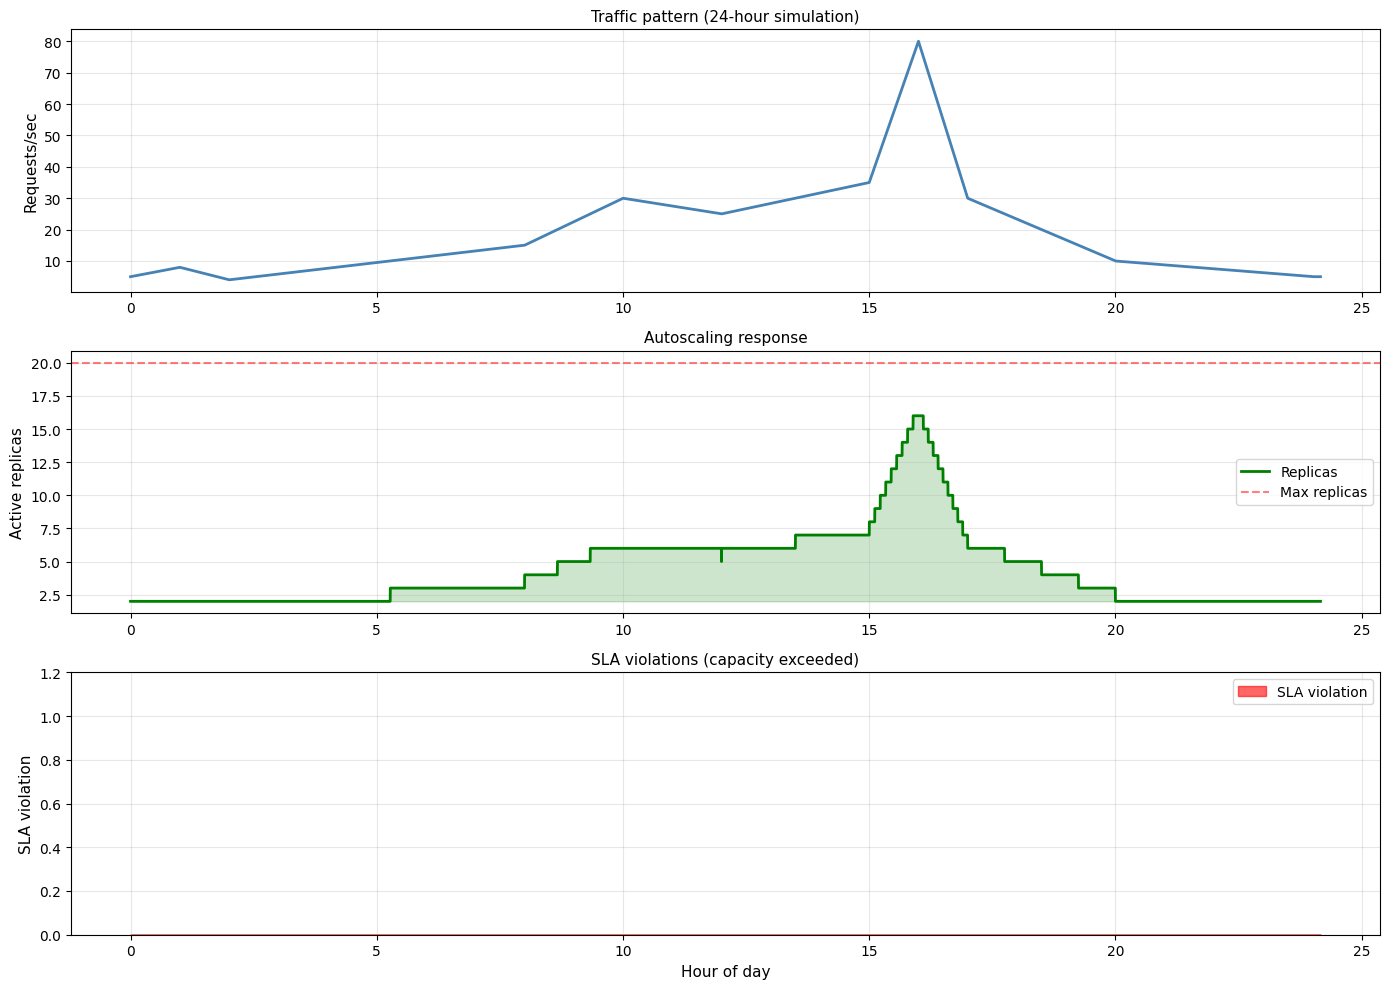

SLA violations: 0/8700 intervals (0.0%)
Max replicas reached: 16
Avg replicas: 4.4


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random

random.seed(42)

def simulate_autoscaling(traffic_pattern, min_replicas, max_replicas,
                          concurrency_target, window_sec=60, scale_down_delay_sec=300):
    """
    Simulate autoscaling over time.
    traffic_pattern: list of (time_sec, requests_per_sec) tuples
    Returns: time series of replica count and SLA violations
    """
    total_duration = max(t for t, _ in traffic_pattern) + 600
    times = np.arange(0, total_duration, 10)  # 10-second intervals

    # Interpolate traffic
    traffic_times = [t for t, _ in traffic_pattern]
    traffic_rates = [r for _, r in traffic_pattern]
    rps = np.interp(times, traffic_times, traffic_rates)

    replicas = [min_replicas]
    sla_violations = [False]
    last_scale_down = -scale_down_delay_sec

    for i in range(1, len(times)):
        t = times[i]
        current_rps = rps[i]

        # Traffic-based scaling
        replicas_needed = max(min_replicas,
                              min(max_replicas,
                                  int(np.ceil(current_rps / concurrency_target))))

        current = replicas[-1]

        if replicas_needed > current:
            # Scale up immediately (with cold start delay in reality)
            new_replicas = replicas_needed
        elif replicas_needed < current and t - last_scale_down > scale_down_delay_sec:
            # Scale down after delay
            new_replicas = max(min_replicas, replicas_needed)
            last_scale_down = t
        else:
            new_replicas = current

        replicas.append(new_replicas)

        # SLA violation if traffic exceeds capacity
        capacity = new_replicas * concurrency_target
        sla_violations.append(current_rps > capacity * 1.1)  # 10% headroom

    return times, np.array(replicas), np.array(sla_violations), rps

# Simulate a daily traffic pattern with a spike
traffic_pattern = [
    (0,    5),    # 00:00: low traffic
    (3600, 8),    # 01:00: slight increase
    (7200, 4),    # 02:00: low
    (28800, 15),  # 08:00: morning traffic
    (36000, 30),  # 10:00: peak
    (43200, 25),  # 12:00: lunch
    (54000, 35),  # 15:00: afternoon peak
    (57600, 80),  # 16:00: traffic spike!
    (61200, 30),  # 17:00: returns to normal
    (72000, 10),  # 20:00: evening
    (86400, 5),   # 24:00: night
]

times, replicas, violations, rps = simulate_autoscaling(
    traffic_pattern,
    min_replicas=2,
    max_replicas=20,
    concurrency_target=5,
    scale_down_delay_sec=300
)

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Traffic
axes[0].plot(times / 3600, rps, color='steelblue', linewidth=2)
axes[0].set_ylabel("Requests/sec", fontsize=11)
axes[0].set_title("Traffic pattern (24-hour simulation)", fontsize=11)
axes[0].grid(True, alpha=0.3)

# Replicas
axes[1].plot(times / 3600, replicas, color='green', linewidth=2, label="Replicas")
axes[1].fill_between(times / 3600, 2, replicas, alpha=0.2, color='green')
axes[1].set_ylabel("Active replicas", fontsize=11)
axes[1].set_title("Autoscaling response", fontsize=11)
axes[1].axhline(y=20, color='red', linestyle='--', alpha=0.5, label='Max replicas')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# SLA violations
axes[2].fill_between(times / 3600, violations.astype(float),
                     alpha=0.6, color='red', label='SLA violation')
axes[2].set_ylabel("SLA violation", fontsize=11)
axes[2].set_xlabel("Hour of day", fontsize=11)
axes[2].set_title("SLA violations (capacity exceeded)", fontsize=11)
axes[2].set_ylim(0, 1.2)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

n_violations = violations.sum()
total_points = len(violations)
print(f"SLA violations: {n_violations}/{total_points} intervals ({n_violations/total_points*100:.1f}%)")
print(f"Max replicas reached: {replicas.max()}")
print(f"Avg replicas: {replicas.mean():.1f}")

## Concurrency and Throughput Model: Where the Replica Limit Comes From

Maximum concurrent requests per replica is set by KV cache memory, not by compute. After the model loads, whatever GPU memory is left divides among the per-token KV cache footprint of every active request. Throughput in turn is HBM-bandwidth-bound during decode — large batches help until compute caps in, after which more batching no longer buys throughput.

In [5]:
def max_concurrent_requests(gpu_memory_gb: float, model_gb: float,
                              seq_len: int, n_layers: int,
                              n_kv_heads: int, head_dim: int, dtype_bytes=2) -> int:
    """Concurrency cap is set by free GPU memory divided by per-token KV bytes."""
    available_gb = gpu_memory_gb - model_gb - 2.0  # 2 GB overhead for activations
    bytes_per_token = 2 * n_layers * n_kv_heads * head_dim * dtype_bytes  # 2 = K + V
    max_tokens = available_gb * 1e9 / bytes_per_token
    return int(max_tokens / seq_len)

def throughput_model(batch_size: int, hbm_bw_tb_s: float,
                     model_gb: float, peak_tflops: float = 1000.0):
    """Return (effective_tps, memory_bound_tps, compute_cap_tps)."""
    bytes_per_token = model_gb * 1e9 * 2  # weights re-read per token in fp16
    tps_decode = batch_size * hbm_bw_tb_s * 1e12 / bytes_per_token
    flops_per_token = model_gb * 1e9 * 2  # ~2x params FLOPs/token
    tps_compute = peak_tflops * 1e12 / flops_per_token
    return min(tps_decode, tps_compute), tps_decode, tps_compute

# H100 80GB serving Llama-3-8B
gpu_gb, model_gb = 80, 16
max_reqs = max_concurrent_requests(gpu_gb, model_gb, seq_len=2048,
                                   n_layers=32, n_kv_heads=8, head_dim=128)
print(f"Max concurrent requests (Llama-3-8B, H100 80GB, 2048 ctx): {max_reqs}")

print(f"\nThroughput vs batch size (Llama-3-8B, H100, HBM 3.35 TB/s, peak 1000 TFLOPS):")
print(f"{'batch':>6} {'effective':>12} {'memory-bound':>14} {'compute-cap':>13} {'regime':>15}")
for bs in [1, 4, 16, 32, 64, 128, 256, 299, 512, 1024, 2048]:
    eff, mem, comp = throughput_model(bs, 3.35, model_gb)
    regime = "memory-bound" if mem <= comp else "compute-bound"
    print(f"  {bs:4d} {eff:12.0f} {mem:14.0f} {comp:13.0f} {regime:>15}")
print()
print("In the memory-bound regime, doubling the batch doubles throughput because")
print("the weights are read from HBM once and reused across the entire batch.")
print("Around batch=299 (~31,250 tok/s), the compute cap kicks in and the curve")
print("flattens — adding more concurrent requests no longer buys throughput.")

Max concurrent requests (Llama-3-8B, H100 80GB, 2048 ctx): 230

Throughput vs batch size (Llama-3-8B, H100, HBM 3.35 TB/s, peak 1000 TFLOPS):
 batch    effective   memory-bound   compute-cap          regime
     1          105            105         31250    memory-bound
     4          419            419         31250    memory-bound
    16         1675           1675         31250    memory-bound
    32         3350           3350         31250    memory-bound
    64         6700           6700         31250    memory-bound
   128        13400          13400         31250    memory-bound
   256        26800          26800         31250    memory-bound
   299        31250          31302         31250   compute-bound
   512        31250          53600         31250   compute-bound
  1024        31250         107200         31250   compute-bound
  2048        31250         214400         31250   compute-bound

In the memory-bound regime, doubling the batch doubles throughput because
the

## Part 2: Cold Starts — The Autoscaling Bottleneck

Cold start is the time to spin up a new replica from zero. The components:

1. **GPU procurement:** Cloud provider allocates GPU hardware (~seconds to minutes)
2. **Image loading:** Pull container image to new instance (~minutes for 12GB image)
3. **Model weight loading:** Load weights into GPU VRAM (~minutes for 140GB)
4. **Engine startup:** Start inference engine, compile kernels (~seconds to minutes)

Cold start bottleneck: if you can't spin up replicas fast, you can't scale down aggressively (you'll overprovision to buffer against spikes).

In [6]:
# Model cold start time components and optimization strategies

cold_start_stages = {
    "GPU procurement": {
        "baseline_sec": 30,
        "optimized_sec": 10,
        "optimization": "Warm pool of pre-allocated GPUs"
    },
    "Image loading (12GB)": {
        "baseline_sec": 120,   # 12GB at 100MB/s
        "optimized_sec": 12,   # 12GB at 1GB/s (fast CDN/local cache)
        "optimization": "Local image cache, smaller images"
    },
    "Model weights (70B FP16 = 140GB)": {
        "baseline_sec": 467,   # 140GB at 300MB/s (S3)
        "optimized_sec": 42,   # 140GB at 3.35GB/s (NVMe + fast network)
        "optimization": "Local NVMe cache, quantized weights (INT4=35GB)"
    },
    "Engine startup (vLLM)": {
        "baseline_sec": 10,
        "optimized_sec": 8,
        "optimization": "Minimal: vLLM starts fast"
    },
    "Engine startup (TRT-LLM)": {
        "baseline_sec": 300,   # 5 min compilation
        "optimized_sec": 30,   # Cached compiled engine
        "optimization": "Cache compiled TRT-LLM engine"
    },
}

print("Cold start time analysis (70B model on H100)")
print()
print(f"{'Stage':<35} {'Baseline':>12} {'Optimized':>12} {'Optimization'}")
print("-" * 95)

total_baseline = 0
total_optimized = 0

for stage, times in cold_start_stages.items():
    total_baseline += times["baseline_sec"]
    total_optimized += times["optimized_sec"]
    opt_desc = times["optimization"][:40]
    print(f"{stage:<35} {times['baseline_sec']:>10}s  {times['optimized_sec']:>10}s  {opt_desc}")

print("-" * 95)
print(f"{'Total':>35} {total_baseline:>10}s  {total_optimized:>10}s")
print()
print(f"Baseline cold start: {total_baseline/60:.1f} minutes")
print(f"Optimized cold start: {total_optimized/60:.1f} minutes")
print(f"Speedup: {total_baseline/total_optimized:.1f}x")
print()
print("Key bottleneck: model weight loading dominates baseline cold start time.")
print("INT4 quantization (4x smaller weights) directly reduces this by 4x.")

Cold start time analysis (70B model on H100)

Stage                                   Baseline    Optimized Optimization
-----------------------------------------------------------------------------------------------
GPU procurement                             30s          10s  Warm pool of pre-allocated GPUs
Image loading (12GB)                       120s          12s  Local image cache, smaller images
Model weights (70B FP16 = 140GB)           467s          42s  Local NVMe cache, quantized weights (INT
Engine startup (vLLM)                       10s           8s  Minimal: vLLM starts fast
Engine startup (TRT-LLM)                   300s          30s  Cache compiled TRT-LLM engine
-----------------------------------------------------------------------------------------------
                              Total        927s         102s

Baseline cold start: 15.4 minutes
Optimized cold start: 1.7 minutes
Speedup: 9.1x

Key bottleneck: model weight loading dominates baseline cold start ti

## Scale-to-Zero, Warm Pools, and the Cold-Start vs Idle-Cost Frontier

Knowing where cold-start time goes is the first half of the problem. The second is choosing a deployment strategy along the trade-off curve: keep replicas warm (cheap latency, expensive idle), pre-warm based on forecasts (cheap if forecasts are right), or scale to zero with a cached model (cheapest idle, slow first request). The right answer depends on traffic shape, not on a universal best-practice.

In [7]:
# Five strategies along the cold-start vs idle-cost frontier.
# Costs are illustrative for an H100 ($4.50/hr full price).

strategies = {
    "Always-on (1 replica)": {
        "cold_start_ms": 0,
        "idle_cost_per_hr": 4.50,
        "description": "Min 1 replica running at all times — no cold start.",
    },
    "Warm pool (1 spare)": {
        "cold_start_ms": 0,
        "idle_cost_per_hr": 9.00,
        "description": "One pre-warmed replica in addition to active capacity.",
    },
    "Predictive scale-up": {
        "cold_start_ms": 300_000,  # 5 min, but scheduled before the spike
        "idle_cost_per_hr": 4.50,
        "description": "Forecast-based pre-warming so cold start lands during slack.",
    },
    "Scale-to-zero + model cache": {
        "cold_start_ms": 90_000,   # 90s with weights on local NVMe
        "idle_cost_per_hr": 0.10,  # storage cost only
        "description": "Zero idle GPU cost; weights cached on fast NVMe.",
    },
    "Serverless (cold cache)": {
        "cold_start_ms": 300_000,
        "idle_cost_per_hr": 0.0,
        "description": "True zero idle cost, worst cold-start on first request.",
    },
}

print(f"{'Strategy':<32} {'Cold start':>12} {'Idle $/hr':>12}")
print("-" * 60)
for name, info in strategies.items():
    print(f"{name:<32} {info['cold_start_ms']/1000:>10.0f}s "
          f"{info['idle_cost_per_hr']:>11.2f}")
    print(f"  {info['description']}")
print()
print("The right strategy depends on traffic shape: bursty + predictable favors")
print("predictive pre-warm; bursty + unpredictable favors warm pools; long idle")
print("periods favor scale-to-zero with a cached model.")

Strategy                           Cold start    Idle $/hr
------------------------------------------------------------
Always-on (1 replica)                     0s        4.50
  Min 1 replica running at all times — no cold start.
Warm pool (1 spare)                       0s        9.00
  One pre-warmed replica in addition to active capacity.
Predictive scale-up                     300s        4.50
  Forecast-based pre-warming so cold start lands during slack.
Scale-to-zero + model cache              90s        0.10
  Zero idle GPU cost; weights cached on fast NVMe.
Serverless (cold cache)                 300s        0.00
  True zero idle cost, worst cold-start on first request.

The right strategy depends on traffic shape: bursty + predictable favors
predictive pre-warm; bursty + unpredictable favors warm pools; long idle
periods favor scale-to-zero with a cached model.


## Try These Experiments

**Tune the simulator**

1. **Scale-down delay calibration:** Sweep `scale_down_delay_sec` over [60, 120, 300, 600, 900]. Plot the tradeoff between SLA violations (too aggressive) and average idle replicas (too conservative). What delay minimizes cost while keeping violations below 5%?
2. **Concurrency target sweep:** Sweep `concurrency_target` from 2 to 20 against the same traffic pattern. Plot estimated P50 and P95 latency as a function of target.
3. **Scale to zero:** Add scale-to-zero to the simulator — when traffic is 0 for >5 minutes, drop to 0 replicas, and apply a cold-start delay on the first request that arrives after. Measure the impact on P99 latency for overnight traffic.

**Build something extra**

4. **Predictive scale-up:** Implement an autoscaler that uses a 15-minute moving average of request rate to pre-warm replicas before a forecasted spike. Compare SLA-violation count against the reactive baseline.
5. **Cost optimization:** For a chosen 24-hour traffic pattern, find the `min_replicas` value that minimizes total cost while keeping P99 cold-start exposure under 1 second.
6. **Real measurement:** On spark-01, run `time vllm serve --model meta-llama/Llama-3.2-1B-Instruct` and compare actual model load time against the theoretical estimate from the cold-start table.

## Key Takeaways

- Five autoscaling parameters set the policy: min replicas, max replicas, autoscaling window, scale-down delay, concurrency target.
- Use both **traffic** (request rate, queue depth — leading indicator) and **utilization** (GPU compute/memory — lagging indicator) as scaling signals.
- **Maximum concurrency per replica is bounded by KV cache memory**, not compute. The free GPU memory after the model loads, divided by per-token KV bytes, divided by sequence length, gives the headroom for concurrent requests.
- Cold start is the central autoscaling constraint — for a 70B model, baseline cold start is ~15 minutes, of which model-weight loading dominates. Local NVMe weight cache and INT4 quantization (4× smaller) bring this to under a minute.
- The cold-start vs idle-cost tradeoff defines the strategy: always-on pays for idle GPUs but eliminates cold start; scale-to-zero with a model cache pays nearly zero idle cost at the price of a ~90-second first request; warm pools sit between.
- Scale-down delay prevents flapping for spiky traffic — the cost is paying for replicas that traffic has already left behind.
- **What's next:** Day 24 — Routing, Load Balancing & Queueing.

## References
- *Inference Engineering* Ch 7.2 (pp. 183–192) — Philip Kiely
- [KEDA: Kubernetes Event-Driven Autoscaling](https://keda.sh/)
- [vLLM serve documentation](https://docs.vllm.ai/en/latest/serving/openai_compatible_server.html)